# Tráfico

En este notebook vamos a trabajar con los datos de tráfico parquet descargados en los notebooks `descargar_traffic.py` y `descargar_traffic2.py`.

Hemos conseguido millones de datos de tráfico de más de 1.000 segmentos diferentes de la ciudad de Chicago, entre los años 2018 y 2026.

## 0. Importación de librerías

In [ ]:
import duckdb
import pandas as pd
pd.set_option("display.max_rows", 5)
pd.set_option("display.max_columns", None)

import matplotlib.pyplot as plt

from pathlib import Path

import folium
from folium.plugins import HeatMap

## 1. Reducir tamaño

Antes de empezar, vamos a ver cuantas filas y columnas hemos conseguido para los datos de tráfico.

In [101]:
# num de filas de traffic
con = duckdb.connect()
con.sql("""
    SELECT COUNT(*) AS n_filas
    FROM 'chicago_traffic_data/*.parquet'
""").df()

,n_filas
0,223544118


In [102]:
# num de columnas de traffic
con.sql("""
    SELECT COUNT(*) AS n_columnas
    FROM (
        DESCRIBE
        SELECT *
        FROM 'chicago_traffic_data/*.parquet'
    )
""").df()

,n_columnas
0,14


La carpeta de datos de tráfico que hemos descargado es demasiado grande (223.544.118 filas y 14 columnas) para trabajar con ella en pandas, así que el primer paso será reducir el tamaño. En vez de tener una fila por segmento cada pocos minutos, que son millones de filas, vamos a crear una fila por segmento y por hora para así tener muchas menos filas.

Para esto usamos `DuckDB`, ya que nos permite consultar directamente los archivos parquet y realizar las operaciones de agrupación y cálculo sobre ellos antes de cargar el resultado reducido en pandas.

In [103]:
# convertimos las observaciones durante una hora de un mismo 
# segmento en una única fila

# creamos conexion con duckdb
con = duckdb.connect()

# consulta SQL para agregar las observaciones por segmento y hora
df_traffic_hourly = con.sql("""
    SELECT
        segment_id,
        street,
        direction,
        start_latitude,
        start_longitude,
        end_latitude,
        end_longitude,
        date_trunc('hour', CAST(time AS TIMESTAMP)) AS time_hour,
        AVG(speed) AS avg_speed,
        COUNT(*) AS n_lecturas
    FROM 'chicago_traffic_data/*.parquet'
    GROUP BY segment_id, street, direction, start_latitude, start_longitude,
             end_latitude, end_longitude, time_hour
""").df()

In [104]:
# dimension de df_traffic_hourly
df_traffic_hourly.shape

(54236883, 10)

Ahora `df_traffic_hourly` tiene dimensiones de (54.236.883, 10). Aunque hemos reducimo bastante el número de filas, el tamaño del dataframe sigue siendo muy grande, por lo que vamos a separarlo en dos tablas:

1. `dim_segmentos`: tabla con una fila por segmento, con su calle, dirección y coordenadas.
2. `fact_traffic_hourly`: tabla con `segment_id`, `time_hour`, `avg_speed` y `n_lecturas`.

Por lo tanto cuando necesitemos la calle o las coordenadas de un segmento las busamos en `dim_segmentos`en vez de buscarla en una tabla mucho más grande.

In [105]:
# creamos tabla dim_segmentos
dim_segmentos = con.sql("""
    SELECT DISTINCT
        segment_id, street, direction,
        start_latitude, start_longitude,
        end_latitude, end_longitude
    FROM 'chicago_traffic_data/*.parquet'
""").df()

# guardamos en parquet
dim_segmentos.to_parquet("data_clean/dim_segmentos.parquet")
print(dim_segmentos.shape)

(1906, 7)


Conseguimos reducir los 54 millones de registros a solo 1.906 filas para la información que no cambia con el tiempo.

Aun así, este código nos garantiza una fila por combinación exacta de las 7 columnas. Cabe la posibilidad de que, como tenemos datos de años diferentes, alguna variable de un segmento cambien ligeramente por año, por lo que tendriamos varias filas con el mismo `segment_id`. Lo comprobamos:

In [106]:
con.sql("""
    SELECT
        segment_id,
        COUNT(*) AS n_combinaciones
    FROM (
        SELECT DISTINCT
            segment_id,
            street,
            direction,
            start_latitude,
            start_longitude,
            end_latitude,
            end_longitude
        FROM 'chicago_traffic_data/*.parquet'
    )
    GROUP BY segment_id
    HAVING COUNT(*) > 1
    ORDER BY n_combinaciones DESC
""").df()

,segment_id,n_combinaciones
0,132,2
1,134,2
2,137,2
3,139,2
4,143,2
5,154,2
6,156,2
7,155,2
8,168,2
9,166,2


Obtenemos 860 filas donde `segment_id` esta duplicado, es decir, 430 segmentos aparecen dos veces. Veamos para cada segmento problemático qué columna es la que realmente cambia.

In [107]:
con.sql("""
    SELECT
        segment_id,
        COUNT(DISTINCT street) AS n_street,
        COUNT(DISTINCT direction) AS n_direction,
        COUNT(DISTINCT start_latitude) AS n_start_lat,
        COUNT(DISTINCT start_longitude) AS n_start_lon,
        COUNT(DISTINCT end_latitude) AS n_end_lat,
        COUNT(DISTINCT end_longitude) AS n_end_lon
    FROM 'chicago_traffic_data/*.parquet'
    GROUP BY segment_id
    HAVING COUNT(DISTINCT street) > 1
        OR COUNT(DISTINCT direction) > 1
        OR COUNT(DISTINCT start_latitude) > 1
        OR COUNT(DISTINCT start_longitude) > 1
        OR COUNT(DISTINCT end_latitude) > 1
        OR COUNT(DISTINCT end_longitude) > 1
""").df()

,segment_id,n_street,n_direction,n_start_lat,n_start_lon,n_end_lat,n_end_lon
0,647,1,1,2,2,2,2
1,643,1,1,2,2,2,2
2,639,1,1,2,2,2,2
3,636,1,1,2,2,2,2
4,644,1,1,2,2,2,2
5,684,1,1,2,2,2,2
6,700,1,1,2,2,2,2
7,696,1,1,2,2,2,2
8,687,1,1,2,2,2,2
9,689,1,1,2,2,2,2


Vemos que en todos los segmentos duplicados el problema es que las coordenadas cambian, vamos a ver cuanto cambian estas coordenas:

In [108]:
cambios_coords = con.sql("""
    SELECT
        segment_id,
        MAX(start_latitude) - MIN(start_latitude) AS diff_start_lat,
        MAX(start_longitude) - MIN(start_longitude) AS diff_start_lon,
        MAX(end_latitude) - MIN(end_latitude) AS diff_end_lat,
        MAX(end_longitude) - MIN(end_longitude) AS diff_end_lon
    FROM 'chicago_traffic_data/*.parquet'
    GROUP BY segment_id
    HAVING
        MAX(start_latitude) != MIN(start_latitude)
        OR MAX(start_longitude) != MIN(start_longitude)
        OR MAX(end_latitude) != MIN(end_latitude)
        OR MAX(end_longitude) != MIN(end_longitude)
""").df()

cambios_coords.describe()

,segment_id,diff_start_lat,diff_start_lon,diff_end_lat,diff_end_lon
count,860.000000,8.600000e+02,8.600000e+02,8.600000e+02,8.600000e+02
mean,499.003488,2.486395e-09,2.548954e-09,2.465349e-09,2.518605e-09
std,321.790380,1.438272e-09,1.467755e-09,1.457264e-09,1.491240e-09
min,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,226.750000,1.300002e-09,1.299995e-09,1.200000e-09,1.100005e-09
50%,455.500000,2.449998e-09,2.600004e-09,2.400000e-09,2.549996e-09
75%,772.250000,3.799997e-09,3.800011e-09,3.799997e-09,3.800011e-09
max,1193.000000,4.999997e-09,5.000004e-09,5.000004e-09,5.000004e-09


Como las diferencias son muy pequeñas, utilizamos la media de las coordenadas para quedarnos solo con una fila por segemento.

In [109]:
dim_segmentos = con.sql("""
    SELECT
        segment_id,
        ANY_VALUE(street) AS street,
        ANY_VALUE(direction) AS direction,
        AVG(start_latitude) AS start_latitude,
        AVG(start_longitude) AS start_longitude,
        AVG(end_latitude) AS end_latitude,
        AVG(end_longitude) AS end_longitude
    FROM 'chicago_traffic_data/*.parquet'
    GROUP BY segment_id
""").df()

dim_segmentos.to_parquet("data_clean/dim_segmentos.parquet")

print(dim_segmentos.shape)

(1046, 7)


Ahora sí, conseguimos reducir los 54 millones de registros a solo 1.046 segmentos únicos para la información que no cambia con el tiempo. A continuación creamos la tabla `fact_traffic_hourly`.

In [110]:
# agregamos filas por segmento y hora
con.sql("""
    COPY (
        SELECT
            segment_id,
            date_trunc('hour', CAST(time AS TIMESTAMP)) AS time_hour,
            AVG(speed) AS avg_speed,
            COUNT(*) AS n_lecturas
        FROM 'chicago_traffic_data/*.parquet'
        GROUP BY segment_id, time_hour
    ) TO 'data_clean/fact_traffic_hourly.parquet' (FORMAT PARQUET)
""")

In [111]:
# comprobamos filas
filas = con.sql("SELECT COUNT(*) AS filas FROM 'data_clean/fact_traffic_hourly.parquet'").df()
print(filas)

# cuantos MB ocupa en disco
import os
print(os.path.getsize("data_clean/fact_traffic_hourly.parquet") / 1e6, "MB")

      filas
0  54222131
169.297929 MB


Vemos que hemos pasado de 54.236.883 a 54.222.131 filas de tráfico, vamos a comprobar si es por las duplicaciones de los segmentos por la diferencia de coordenadas (ya que ahora solo agrupamos por `segment_id` y `time_hour` por lo que las filas no se duplican):

In [112]:
con.sql("""
    SELECT
        segment_id,
        time_hour,
        COUNT(*) AS n_combinaciones
    FROM (
        SELECT DISTINCT
            segment_id,
            date_trunc('hour', CAST(time AS TIMESTAMP)) AS time_hour,
            street,
            direction,
            start_latitude,
            start_longitude,
            end_latitude,
            end_longitude
        FROM 'chicago_traffic_data/*.parquet'
    )
    GROUP BY segment_id, time_hour
    HAVING COUNT(*) > 1
    ORDER BY n_combinaciones DESC
""").df()

,segment_id,time_hour,n_combinaciones
0,939,2018-03-01 10:00:00,2
1,708,2018-03-01 11:00:00,2
2,161,2018-03-01 12:00:00,2
3,755,2018-03-01 12:00:00,2
4,162,2018-03-01 13:00:00,2
5,173,2018-03-01 14:00:00,2
6,302,2018-03-01 15:00:00,2
7,947,2018-03-01 15:00:00,2
8,806,2018-03-01 15:00:00,2
9,73,2018-03-01 10:00:00,2


Agrupandolas por `segment_id` y `time_hour` conseguimos 14.752 filas duplicadas, exactamente la diferencia que hemos encontrado. Por lo tanto ya tenemos el archivo `dim_segmentos.parquet` con dimensiones (10)

## 2. Unir los eventos

Una vez tengamos todos los datasets limpios, empezamos a unir los diferentes datos.

Nota: los demás datos se han limpiado para empezar desde el año 2015, sin embargo, por falta de datos de tráfico, vamos a usarlos desde abril de 2018 hasta 2026.

### 2.1. Unir festivos

`holidays.csv` contiene:
- `date`: fecha
- `school_holiday`: indica si es vacacion escolar o no
- `festivo`: indica si es día festivo o no

In [113]:
# cargamos el csv de festivos y vacaciones escolares
df_holidays = pd.read_csv("data_clean/holidays.csv")

In [114]:
# unimos festivos por fecha (no tienen hora, son todo el dia)
con.sql("""
    COPY (
        SELECT
            f.*,
            h.school_holiday,
            h.festivo
        FROM 'data_clean/fact_traffic_hourly.parquet' f
        LEFT JOIN df_holidays h
            ON CAST(f.time_hour AS DATE) = CAST(h.date AS DATE)
    ) TO 'data_clean/fact_traffic_hourly_v2.parquet' (FORMAT PARQUET)
""")

### 2.2. Unir clima

El archivo `weather_data.csv` contiene:
- `date`: fecha y hora
- `temperature_2m`: temperatura a 2 metros
- `rain`: lluvia
- `snowfall`: nieve
- `relative_humidity_2m`: humedad relativa a 2 metros
- `wind_speed_10m`: velocidad del viento a 10 metros

In [115]:
# cargamos dataset de clima
df_weather = pd.read_csv("data_clean/weather_data.csv")

In [116]:
# unimos clima por fecha + hora
con.sql("""
    COPY (
        SELECT
            f.*,
            w.temperature_2m,
            w.rain,
            w.snowfall,
            w.relative_humidity_2m,
            w.wind_speed_10m
        FROM 'data_clean/fact_traffic_hourly_v2.parquet' f
        LEFT JOIN df_weather w
            ON f.time_hour = date_trunc('hour', CAST(w.date AS TIMESTAMP))
    ) TO 'data_clean/fact_traffic_hourly_v3.parquet' (FORMAT PARQUET)
""")

In [117]:
# comprobamos los codigos de festivos + clima
check = con.sql("""
    SELECT festivo, COUNT(*) AS n
    FROM 'data_clean/fact_traffic_hourly_v3.parquet'
    GROUP BY festivo
""").df()
print(check)

con.sql("SELECT * FROM 'data_clean/fact_traffic_hourly_v3.parquet' LIMIT 5").df()

   festivo         n
0        0  52202015
1        1   2020116


,segment_id,time_hour,avg_speed,n_lecturas,school_holiday,festivo,temperature_2m,rain,snowfall,relative_humidity_2m,wind_speed_10m
0,141,2018-03-13 09:00:00,27.625,8,0,0,-2.5,0.0,0.0,72.59279,18.089775
1,127,2018-03-13 09:00:00,26.375,8,0,0,-2.5,0.0,0.0,72.59279,18.089775
2,134,2018-03-13 09:00:00,24.250,8,0,0,-2.5,0.0,0.0,72.59279,18.089775
3,140,2018-03-13 09:00:00,28.625,8,0,0,-2.5,0.0,0.0,72.59279,18.089775
4,136,2018-03-13 09:00:00,25.000,8,0,0,-2.5,0.0,0.0,72.59279,18.089775


Conseguimos 2.020.116 filas marcadas como festivo sobre 54.222.131, que es un 3,73%.

Antes de seguir, observamos que `df_weather` tiene fechas con zona horaria `2011-01-01 00:00:00+00:00`, donde `+00:00` es UTC, pero creo que la columna de fecha y hora del tráfico está en hora local de Chicago. Vamos a comprobarlo calculando la temperatura media por hora del día y viendo los picos de calor y frío.

In [118]:
check_tz = con.sql("""
    SELECT
        EXTRACT(HOUR FROM time_hour) AS hora,
        AVG(temperature_2m) AS temp_media
    FROM 'data_clean/fact_traffic_hourly_v3.parquet'
    GROUP BY hora
    ORDER BY hora
""").df()

print(check_tz)

    hora  temp_media
0      0   11.815111
1      1   11.158134
2      2   10.739386
3      3   10.297280
4      4    9.955184
5      5    9.647060
6      6    9.355681
7      7    9.091915
8      8    8.886088
9      9    8.664404
10    10    8.425047
11    11    8.266450
12    12    8.773105
13    13    9.329912
14    14   10.225701
15    15   11.253224
16    16   12.177920
17    17   12.921109
18    18   13.498541
19    19   13.886891
20    20   13.999751
21    21   13.901520
22    22   13.482373
23    23   12.812915


Como podemos ver, la temperatura mínima aparece sobre las 11 de la mañana (8.27º), cuando debería ser antes, sobre las 5 o 6 de la mañana, y la máxima aparece sobre las 20:00 (14º) cuando debería de ser hacia las 14:00-16:00. 

Por lo tanto, confirmamos que el clima está en UTC y el tráfico en hora local de Chicago (que va 5 horas por detrás en verano y 6 en invierno). Asi que vamos a corregirlo.

In [119]:
# convertimos la columna date de UTC a hora local de Chicago
df_weather["date"] = pd.to_datetime(df_weather["date"], utc=True)
df_weather["date"] = df_weather["date"].dt.tz_convert("America/Chicago")

# quitamos la información de zona horaria (nos quedamos solo con la hora local),
# porque nuestra tabla de tráfico tampoco la tiene, y para que el JOIN pueda comparar
df_weather["date"] = df_weather["date"].dt.tz_localize(None)

El cambio de horario hace que, al pasar de UTC a hora local de Chicago, la hora 1:00-1:59 del primer domingo de noviembre aparezca dos veces (esa noche el reloj se atrasa una hora). Como el clima viene en resolución horaria, `df_weather` acaba con dos filas para esa hora local (con temperatura/humedad distintas), una por cada ocurrencia real en UTC.

Esto hay que arreglarlo, porque sino el `LEFT JOIN` de tráfico con clima generaría una fila de más por cada segmento en esa hora, y ese duplicado se arrastraría a todos los `JOIN` posteriores con accidentes, partidos, conciertos y obras. Lo corregimos ahora colapsando esa hora duplicada en una única fila (promediando los valores numéricos).

In [120]:
n_antes = len(df_weather)

df_weather = df_weather.groupby("date", as_index=False).agg({
    "temperature_2m": "mean",
    "rain": "mean",
    "snowfall": "mean",
    "relative_humidity_2m": "mean",
    "wind_speed_10m": "mean",
})

print(f"Filas de clima antes: {n_antes}, después: {len(df_weather)}, "
      f"horas duplicadas por el cambio horario: {n_antes - len(df_weather)}")

Filas de clima antes: 136584, después: 136569, horas duplicadas por el cambio horario: 15


In [121]:
# repetimos el join de antes con el horario corregido
con.sql("""
    COPY (
        SELECT
            f.*,
            w.temperature_2m,
            w.rain,
            w.snowfall,
            w.relative_humidity_2m,
            w.wind_speed_10m
        FROM 'data_clean/fact_traffic_hourly_v2.parquet' f
        LEFT JOIN df_weather w
            ON f.time_hour = date_trunc('hour', CAST(w.date AS TIMESTAMP))
    ) TO 'data_clean/fact_traffic_hourly_v3.parquet' (FORMAT PARQUET)
""")

In [122]:
# comprobamos los picos de temperatura otra vez
check_tz = con.sql("""
    SELECT
        EXTRACT(HOUR FROM time_hour) AS hora,
        AVG(temperature_2m) AS temp_media
    FROM 'data_clean/fact_traffic_hourly_v3.parquet'
    GROUP BY hora
    ORDER BY hora
""").df()

print(check_tz)

    hora  temp_media
0      0    9.573400
1      1    9.297020
2      2    9.070080
3      3    8.740335
4      4    8.488699
5      5    8.260040
6      6    8.234635
7      7    8.726821
8      8    9.513421
9      9   10.559847
10    10   11.576727
11    11   12.466204
12    12   13.175086
13    13   13.707265
14    14   14.016505
15    15   14.070340
16    16   13.811663
17    17   13.286708
18    18   12.591052
19    19   11.763170
20    20   11.044340
21    21   10.564591
22    22   10.181381
23    23    9.887109


Vemos que ahora tiene sentido, el mínimo esta a las 6:00 y el máximo a las 15:00.

### 2.3. Unir Accidentes

Los accidentes no afectan solo a la calle donde se ha producido, sino que también afecta a las calles vecinas, además, dependiendo de la gravedad, puede durar más o menos tiempo. Para unir los accidnetes al dataset, tenemos en cuenta estos puntos:

- **Radio**: vamos a emparejar los accidentes con los segmentos de la misma calle y que estén a una distancia máxima de 400 m.
- **Ventana temporal**: escalamos según la gravedad del accidente:
 (sin heridos -> corto, ..., fatal -> largo)
- No afecta al tráfico antes, solo después del accidente.

Para saber si un segmento de tráfico está cerca de un accidente, vamos a calcular la distancia entre dos puntos GPS (lat/lon). Para ello vamos a usar la fórmula **Haversine**, que calcula la distancia real sobre la superficie de la Tierra ($d$):

$$
d = 2r\arcsin(\sqrt{\sin^2{(\frac{\phi_2-\phi_1}{2})}+\cos(\phi_1)\cos(\phi_2)\sin^2{(\frac{\lambda_2-\lambda_1}{2})}})
$$

donde:
- $r$: radio de la Tierra
- $\phi_1, \phi_2$: latitud del punto 1 y punto 2
- $\lambda_1, \lambda_2$: longitud del punto 1 y punto 2

El proceso será el siguiente:
1. Calcular la distancia entre cada fila de `dim_segmentos` y cada fila de accidentes. 
2. Nos quedamos solo con los pares donde la distancia sea menor que el radio.
3. Expandimos el accidente temporalmente dependiendo de la gravedad.
4. Lo unimos con `fact_traffic_hourly` por `segment_id` y `time_hour`.

In [123]:
# cargamos dataset de accidentes
df_crashes = pd.read_csv("data_clean/crashes.csv")

In [124]:
# normalizamos los nombres de las calles

# buscamos palabras tipicas de calle
sufijos = r'\s+(AVE|ST|BLVD|DR|RD|PL|CT|PKWY|HWY|LN|WAY|CIR|TER|SQ|EXPY|PLZ|LOOP)$'

# creamos tabla crashes_norm sin sufijos
con.sql(f"""
    CREATE OR REPLACE TABLE crashes_norm AS
    SELECT
        *,
        ROW_NUMBER() OVER () AS crash_id,
        UPPER(TRIM(REGEXP_REPLACE(STREET_NAME, '{sufijos}', ''))) AS street_norm
    FROM df_crashes
""")

# normalizamos segmentos
con.sql(f"""
    CREATE OR REPLACE TABLE segmentos_norm AS
    SELECT *,
        UPPER(TRIM(REGEXP_REPLACE(street, '{sufijos}', ''))) AS street_norm,
        (start_latitude + end_latitude) / 2 AS mid_lat,
        (start_longitude + end_longitude) / 2 AS mid_lon
    FROM dim_segmentos
""")

In [125]:
# funcion Haversine
con.sql("""
    CREATE OR REPLACE MACRO haversine(lat1, lon1, lat2, lon2) AS (
        6371000 * 2 * ASIN(SQRT(
            POWER(SIN(RADIANS(lat2 - lat1) / 2), 2) +
            COS(RADIANS(lat1)) * COS(RADIANS(lat2)) *
            POWER(SIN(RADIANS(lon2 - lon1) / 2), 2)
        ))
    )
""")

Para saber cuanto tiempo afecta cada tipo de accidente según su gravedad, calculamos la ventana temporal de influencia del accidente. Para cada combinación de segmento, día de la semana y hora del día, calculamos la mediana de velocidad histórica (porque es menos sensible a valores extremos que la media).

Vamos a utilizar solo los datos que seran para el entrenamiento del modelo para no caer en *data leakage*. Por lo tanto, calculamos una fecha de corte, 6 meses antes de la última fecha disponible en nuestros datos (abril de 2026). Todo lo anterior a esa fecha será para train, y todo lo posterior será para test.

In [126]:
# split temporal
fecha_corte = con.sql(f"""
    SELECT MAX(time_hour) - INTERVAL 6 MONTH AS corte
    FROM 'data_clean/fact_traffic_hourly_v3.parquet'
""").df()["corte"][0]

print(f"Fecha de corte: {fecha_corte}")

Fecha de corte: 2025-10-30 01:00:00


In [127]:
# calculamos velocidad de referencia
con.sql("""
    CREATE OR REPLACE TABLE baseline AS
    SELECT
        segment_id,
        EXTRACT(DOW FROM time_hour) AS dow,
        EXTRACT(HOUR FROM time_hour) AS hora,
        MEDIAN(avg_speed) AS speed_baseline
    FROM 'data_clean/fact_traffic_hourly_v3.parquet'
    WHERE time_hour <= TIMESTAMP '2025-10-30 01:00:00'
    GROUP BY segment_id, dow, hora
""")

In [128]:
# comparamos velocidad real vs referencia

# posibles relaciones accidente-segmento
con.sql("""
    CREATE OR REPLACE TABLE crash_candidates AS
    SELECT DISTINCT
        c.crash_id,
        c.severity_level,
        s.segment_id,
        date_trunc('hour', CAST(c.CRASH_DATE AS TIMESTAMP)) AS crash_hour
    FROM crashes_norm c
    JOIN segmentos_norm s
        ON c.street_norm = s.street_norm
        AND haversine(c.LATITUDE, c.LONGITUDE, s.mid_lat, s.mid_lon) <= 400
""")

# ventana temporal
crash_window = con.sql("""
    SELECT
        cc.severity_level,
        t.h AS horas_desde_accidente,
        AVG(f.avg_speed - b.speed_baseline) AS deviation_media,
        COUNT(*) AS n
    FROM crash_candidates cc
    CROSS JOIN UNNEST(range(-2, 7)) AS t(h)
    JOIN 'data_clean/fact_traffic_hourly_v3.parquet' f
        ON f.segment_id = cc.segment_id
        AND f.time_hour = cc.crash_hour + INTERVAL (t.h) HOUR
    JOIN baseline b
        ON b.segment_id = cc.segment_id
        AND b.dow = EXTRACT(DOW FROM f.time_hour)
        AND b.hora = EXTRACT(HOUR FROM f.time_hour)
    GROUP BY cc.severity_level, t.h
    ORDER BY cc.severity_level, t.h
""").df()

print(crash_window)

   severity_level  horas_desde_accidente  deviation_media       n
0           fatal                     -2        -0.174095     429
1           fatal                     -1        -0.383162     411
2           fatal                      0        -1.411960     409
3           fatal                      1        -3.622656     396
4           fatal                      2        -1.925431     383
5           fatal                      3        -1.799386     374
6           fatal                      4        -0.993666     374
7           fatal                      5        -0.195899     390
8           fatal                      6        -0.358437     387
9           grave                     -2        -0.164756    6171
10          grave                     -1        -0.192940    6179
11          grave                      0        -0.770471    6150
12          grave                      1        -0.969179    6061
13          grave                      2        -0.406302    5951
14        

Observamos que en todas las filas antes del accidente la desviación ya es negativa, esto se debe a que las calles donde ocurren accidentes suelen presentar velocidades inferiores a su velocidad histórica de referencia, por lo tanto la línea base de velocidad no es 0. Esto nos da un suelo de referencia (~-0.20 a -0.30) con el que comparar.

Conclusiones por severidad:

- `sin_heridos`: la desviación pasa de -0.31 y -0.26 en las dos horas anteriores a -0.52 en la hora 0 y -0.48 en la hora 1. En la hora 2 baja a -0.31, muy cerca del nivel previo. Por lo tanto, la ventana es 0-1h.
- `leve`: la desviación pasa de -0.28 y -0.23 antes del accidente a -0.61 en la hora 0 y -0.60 en la hora 1. En la hora 2 baja a -0.34 y en la hora 3 ya está en -0.18. Por lo tanto, la ventana es 0-2h.
- `grave`: la desviación pasa de -0.19 y -0.17 antes del accidente a -0.77 en la hora 0 y alcanza su máximo efecto en la hora 1 con -0.97. En la hora 2 baja a -0.41 y en la hora 3 a -0.26. Por lo tanto, la ventana es 0-3h.
- `fatal`: la desviación pasa de -0.38 en la hora anterior a -1.41 en la hora 0 y alcanza su máximo efecto en la hora 1 con -3.62. En las horas 2 y 3 sigue siendo considerable con -1.93 y -1.80, en la hora 4 baja a -0.99 y en la hora 5 vuelve a -0.20, cerca del nivel previo. Por lo tanto, la ventana es 0-4h.

In [129]:
# añadimos las ventanas temporales (evitamos duplicados por accidentes solapados)
con.sql("""
    CREATE OR REPLACE TABLE crash_effects AS
    SELECT segment_id, time_hour, severity_level
    FROM (
        SELECT
            s.segment_id,
            date_trunc('hour', CAST(c.CRASH_DATE AS TIMESTAMP)) + INTERVAL (t.h) HOUR AS time_hour,
            c.severity_level,
            ROW_NUMBER() OVER (
                PARTITION BY s.segment_id, date_trunc('hour', CAST(c.CRASH_DATE AS TIMESTAMP)) + INTERVAL (t.h) HOUR
                ORDER BY CASE c.severity_level
                    WHEN 'fatal' THEN 1
                    WHEN 'grave' THEN 2
                    WHEN 'leve' THEN 3
                    ELSE 4
                END
            ) AS rn
        FROM crashes_norm c
        JOIN segmentos_norm s
            ON c.street_norm = s.street_norm
            AND haversine(c.LATITUDE, c.LONGITUDE, s.mid_lat, s.mid_lon) <= 400
        CROSS JOIN UNNEST(range(0,
            CASE c.severity_level
                WHEN 'fatal' THEN 5
                WHEN 'grave' THEN 4
                WHEN 'leve' THEN 3
                ELSE 2
            END
        )) AS t(h)
    )
    WHERE rn = 1
""")

In [130]:
# unimos accidentes a la tabla principal
con.sql("""
    COPY (
        SELECT
            f.*,
            COALESCE(ce.severity_level, 'ninguno') AS accidente_tipo
        FROM 'data_clean/fact_traffic_hourly_v3.parquet' f
        LEFT JOIN crash_effects ce
            ON f.segment_id = ce.segment_id
            AND f.time_hour = ce.time_hour
    ) TO 'data_clean/fact_traffic_hourly_v4.parquet' (FORMAT PARQUET)
""")

check_crashes = con.sql("""
    SELECT accidente_tipo, COUNT(*) AS n
    FROM 'data_clean/fact_traffic_hourly_v4.parquet'
    GROUP BY accidente_tipo
""").df()
print(check_crashes)

  accidente_tipo         n
0        ninguno  53543296
1           leve     53580
2    sin_heridos    599302
3          grave     24017
4          fatal      1936


Por lo tanto, tenemos 678.835 filas con algún accidente cerca sobre el total (~1,25%).

### 2.4. Unir partidos

Seguimos el mismo proceso de los accidente para los partidos. La única diferencia es que los partidos pueden afectar al tráfico antes de que comience el evento, por la llegada de los espectadores, así que vamos a ampliar el rango de análisis hacia atrás. Para determinar la ventana de influencia, utilizamos solo los datos de entrenamiento.

Además, vamos a poner un radio de 1.500m alrededor de la localización del partido y lo vamos a truncar a la hora de inicio del partido.

In [131]:
# cargamos dataset de partidos
df_matches = pd.read_csv("data_clean/matches.csv")

In [132]:
# creamos tabla con los partidos y añadimos match_id a cada
con.sql("""
    CREATE OR REPLACE TABLE matches_norm AS
    SELECT *, ROW_NUMBER() OVER () AS match_id
    FROM df_matches
""")

# relacionamos partidos - segmentos
con.sql("""
    CREATE OR REPLACE TABLE match_candidates AS
    SELECT DISTINCT
        m.match_id,
        s.segment_id,
        date_trunc('hour', CAST(m.date AS TIMESTAMP)) AS match_hour
    FROM matches_norm m
    JOIN segmentos_norm s
        ON haversine(m.latitude, m.longitude, s.mid_lat, s.mid_lon) <= 1500
""")

In [133]:
# ventana de tiempo (-4h y +8h)

match_window = con.sql("""
    SELECT
        t.h AS horas_desde_partido,
        AVG(f.avg_speed - b.speed_baseline) AS deviation_media,
        COUNT(*) AS n
    FROM match_candidates mc
    CROSS JOIN UNNEST(range(-4, 9)) AS t(h)
    JOIN 'data_clean/fact_traffic_hourly_v3.parquet' f
        ON f.segment_id = mc.segment_id
        AND f.time_hour = mc.match_hour + INTERVAL (t.h) HOUR
    JOIN baseline b
        ON b.segment_id = mc.segment_id
        AND b.dow = EXTRACT(DOW FROM f.time_hour)
        AND b.hora = EXTRACT(HOUR FROM f.time_hour)
    WHERE mc.match_hour <= TIMESTAMP '2025-10-30 01:00:00'
        AND f.time_hour <= TIMESTAMP '2025-10-30 01:00:00'
    GROUP BY t.h
    ORDER BY t.h
""").df()

pd.set_option("display.max_rows", None)
print(match_window)

    horas_desde_partido  deviation_media      n
0                    -4        -0.251731  32935
1                    -3        -0.349917  33262
2                    -2        -0.460978  33855
3                    -1        -0.557666  33877
4                     0        -0.568232  33136
5                     1        -0.354423  32607
6                     2        -0.494866  32718
7                     3        -0.927346  32561
8                     4        -0.524698  30891
9                     5        -0.145290  28713
10                    6        -0.061479  25924
11                    7        -0.061022  21892
12                    8        -0.095782  20327


Aquí vemos que empieza en -0.25 a la hora -4, después va subiendo hasta el primer máximo de desviación en la hora -1 (-0.56), que se interpreta como gente llegando al partido. En la hora 0 se mantiene elevada (-0.57), pero después baja en la hora 1. Vuelve a subir a la hora 2 horas con otro máximo de desviación a la hora 3 (-0.93), lo que sería la salida de la gente al terminar el partido. Después vuelve a bajar llegando a -0.15 en la hora 5.

Por lo tanto, la ventana será de -4 horas antes a 4 horas después del inicio de partido.

In [134]:
# aplicamos la ventana
con.sql("""
    CREATE OR REPLACE TABLE match_effects AS
    SELECT DISTINCT
        mc.segment_id,
        mc.match_hour + INTERVAL (t.h) HOUR AS time_hour,
        1 AS partido
    FROM match_candidates mc
    CROSS JOIN UNNEST(range(-4, 5)) AS t(h)
""")

# unimos a la tabla
con.sql("""
    COPY (
        SELECT
            f.*,
            COALESCE(me.partido, 0) AS partido
        FROM 'data_clean/fact_traffic_hourly_v4.parquet' f
        LEFT JOIN match_effects me
            ON f.segment_id = me.segment_id
            AND f.time_hour = me.time_hour
    ) TO 'data_clean/fact_traffic_hourly_v5.parquet' (FORMAT PARQUET)
""")

# comprobamos
check_matches = con.sql("""
    SELECT partido, COUNT(*) AS n
    FROM 'data_clean/fact_traffic_hourly_v5.parquet'
    GROUP BY partido
""").df()
print(check_matches)

   partido         n
0        0  53911067
1        1    311064


Por lo tanto, tenemos 311.064 filas afectadas por partidos (~0,57%), con un radio de 1.5km y ventana de 9h.

### 2.5. Unir conciertos

A continuación unimos los conciertos de Chicago a la tabla. Seguimos el mismo procedimiento que los partidos, sin embargo, pero en este caso tenemos una limitación: `setlist.fm` no nos da la hora de inicio de los conciertos, asi que no podemos calcular la ventana de influencia con la misma precisión. 

Por lo tanto, vamos a asumir una hora de referencia, las 20:00 (es la habitual), y vamos a comprobar si el patrón de desviación tiene sentido. Aquí tambien utilizamos unicamente los datos de entrenamiento.

In [135]:
# cargamos conciertos
df_concerts = pd.read_csv("data_clean/concerts.csv")

In [136]:
# tabla de conciertos con concert_id y establecemos hora 20:00
con.sql("""
    CREATE OR REPLACE TABLE concerts_norm AS
    SELECT *, ROW_NUMBER() OVER () AS concert_id,
        CAST(date AS DATE) + INTERVAL 20 HOUR AS assumed_hour
    FROM df_concerts
""")

# relacionamos conciertos - segmentos
con.sql("""
    CREATE OR REPLACE TABLE concert_candidates AS
    SELECT DISTINCT
        c.concert_id,
        s.segment_id,
        c.assumed_hour
    FROM concerts_norm c
    JOIN segmentos_norm s
        ON haversine(c.latitude, c.longitude, s.mid_lat, s.mid_lon) <= 1500
""")

In [137]:
# medimos la desviacion alrededor de las 20:00 (-10h, +8h)
concert_window = con.sql("""
    SELECT
        t.h AS horas_desde_hora_asumida,
        AVG(f.avg_speed - b.speed_baseline) AS deviation_media,
        COUNT(*) AS n
    FROM concert_candidates cc
    CROSS JOIN UNNEST(range(-10, 9)) AS t(h)
    JOIN 'data_clean/fact_traffic_hourly_v3.parquet' f
        ON f.segment_id = cc.segment_id
        AND f.time_hour = cc.assumed_hour + INTERVAL (t.h) HOUR
    JOIN baseline b
        ON b.segment_id = cc.segment_id
        AND b.dow = EXTRACT(DOW FROM f.time_hour)
        AND b.hora = EXTRACT(HOUR FROM f.time_hour)
    WHERE cc.assumed_hour <= TIMESTAMP '2025-10-30 01:00:00'
        AND f.time_hour <= TIMESTAMP '2025-10-30 01:00:00'
    GROUP BY t.h
    ORDER BY t.h
""").df()

print(concert_window)

    horas_desde_hora_asumida  deviation_media      n
0                        -10        -0.307457   9808
1                         -9        -0.401085   9722
2                         -8        -0.503096   9765
3                         -7        -0.590289   9740
4                         -6        -0.646517   9784
5                         -5        -0.775785   9814
6                         -4        -0.781207   9888
7                         -3        -0.880133   9999
8                         -2        -0.899852  10392
9                         -1        -0.953767  10245
10                         0        -0.624914   9870
11                         1        -0.476966   9635
12                         2        -0.779067   9717
13                         3        -1.672560   9987
14                         4        -0.973614   9328
15                         5        -0.155128   8225
16                         6         0.083806   6666
17                         7         0.069240 

Observamos que, aun analizando -10 horas antes del concierto, la desviación ya es negativa y nunca llegamos a un suelo (a alrededor de -0.20). La desviación va aumentando progresivamente hasta alcanzar su máximo en la hora -1 (-0.95). Después baja en las horas 0 y 1, vuelve a aumentar en las horas 2 y 3, donde alcanza el mayor efecto (-1.67), y finalmente vuelve a bajar hasta acercarse al nivel de referencia en la hora 5 (-0.16). No tenemos picos tan nítidos sino subidas y bajadas graduales. Esto es normal ya que estamos alineando todos los conciertos en una hora asumida (20:00) que no es la real para mucho casos. 

Por lo tanto, para compensar, vamos a coger una ventana ancha que cubra la mayor parte del efecto (de -8h a 5h). 

In [138]:
# aplicamos la ventana
con.sql("""
    CREATE OR REPLACE TABLE concert_effects AS
    SELECT DISTINCT
        cc.segment_id,
        cc.assumed_hour + INTERVAL (t.h) HOUR AS time_hour,
        1 AS concierto
    FROM concert_candidates cc
    CROSS JOIN UNNEST(range(-8, 6)) AS t(h)
""")

# unimos
con.sql("""
    COPY (
        SELECT
            f.*,
            COALESCE(ce.concierto, 0) AS concierto
        FROM 'data_clean/fact_traffic_hourly_v5.parquet' f
        LEFT JOIN concert_effects ce
            ON f.segment_id = ce.segment_id
            AND f.time_hour = ce.time_hour
    ) TO 'data_clean/fact_traffic_hourly_v6.parquet' (FORMAT PARQUET)
""")

# comprobamos
check_concerts = con.sql("""
    SELECT concierto, COUNT(*) AS n
    FROM 'data_clean/fact_traffic_hourly_v6.parquet'
    GROUP BY concierto
""").df()
print(check_concerts)

   concierto         n
0          0  54079987
1          1    142144


Tenemos 142.144 filas afectadas por conciertos.

### 2.6. Unir obras
Para finalizar, nos falta unir los datos de las obras de la calle a nuestra tabla. En este caso el dataset nos da el rango del tiempo que está activa cada obra (de `APPLICATIONSTARTDATE` a `APPLICATIONENDDATE`). Así que vamos a comprobar si el radio utlizado es adecuado y si el tipo de cierre por obra (`STREETCLOSURE`) genera efectos diferentes sore el tráfico.

In [139]:
# cargamos obras
df_closures = pd.read_csv("data_clean/closures.csv")

In [140]:
# creamos tabla de obras con closure_id
# normalizamos los nombres de las calles
con.sql(f"""
    CREATE OR REPLACE TABLE closures_norm AS
    SELECT
        *,
        ROW_NUMBER() OVER () AS closure_id,
        UPPER(TRIM(REGEXP_REPLACE(STREETNAME, '{sufijos}', ''))) AS street_norm
    FROM df_closures
""")

# emparejamos obras - segmentos con radio de 400m
con.sql("""
    CREATE OR REPLACE TABLE closure_candidates AS
    SELECT DISTINCT
        c.closure_id,
        c.STREETCLOSURE,
        s.segment_id,
        CAST(c.APPLICATIONSTARTDATE AS DATE) AS start_date,
        CAST(c.APPLICATIONENDDATE AS DATE) AS end_date
    FROM closures_norm c
    JOIN segmentos_norm s
        ON c.street_norm = s.street_norm
        AND haversine(c.LATITUDE, c.LONGITUDE, s.mid_lat, s.mid_lon) <= 400
""")

Para comprobar el efecto del tipo de cierre de obra, calculamos la desviación media de la velocidad respecto a su valor de referencia para cada tipo de cierre y contamos el número de observaciones, relacionamos cada obra con las horas en las que está activa sobre los segmentos afectados y unimos cada observación de tráfico con su velocidad histórica de referencia según segmento, día de la semana y hora.

In [141]:
# comprobamos si el tipo de cierre afecta diferente
closure_check = con.sql("""
    SELECT
        cc.STREETCLOSURE,
        AVG(f.avg_speed - b.speed_baseline) AS deviation_media,
        COUNT(*) AS n
    FROM closure_candidates cc
    JOIN 'data_clean/fact_traffic_hourly_v3.parquet' f
        ON f.segment_id = cc.segment_id
        AND CAST(f.time_hour AS DATE) BETWEEN cc.start_date AND cc.end_date
    JOIN baseline b
        ON b.segment_id = cc.segment_id
        AND b.dow = EXTRACT(DOW FROM f.time_hour)
        AND b.hora = EXTRACT(HOUR FROM f.time_hour)
    GROUP BY cc.STREETCLOSURE
    ORDER BY deviation_media
""").df()

print(closure_check)

  STREETCLOSURE  deviation_media         n
0    Intermitte        -0.664999      5209
1          Full        -0.360973   2437733
2       Partial        -0.259103  11170377
3      Curblane        -0.148009  28715175


Confirmamos que el tipo de cierre sí afecta en el tráfico. Aun así, vemos que las obras intermitentes (`intermitte`) son los más fuertes de todos (-0.66), aunque como tienen muy pocos casos comparado con los demás, no es tan fiable. Además, puede deberse a que estas obras tienden a concentrarse en pocas calles concretas que ya de por sí son conflictivas, más que a que el tipo de cierre sea el que más afecta.

En cualquier caso, el patrón general justifica probar `STREETCLOSURE` como variable categórica en el modelo.

In [142]:
# aplicamos y unimos a la tabla
con.sql("""
    CREATE OR REPLACE TABLE closure_effects AS
    SELECT DISTINCT
        cc.segment_id,
        f.time_hour,
        cc.STREETCLOSURE AS obra_tipo
    FROM closure_candidates cc
    JOIN 'data_clean/fact_traffic_hourly_v6.parquet' f
        ON f.segment_id = cc.segment_id
        AND CAST(f.time_hour AS DATE) BETWEEN cc.start_date AND cc.end_date
""")

con.sql("""
    COPY (
        SELECT
            f.*,
            COALESCE(ce.obra_tipo, 'ninguna') AS obra_tipo
        FROM 'data_clean/fact_traffic_hourly_v6.parquet' f
        LEFT JOIN closure_effects ce
            ON f.segment_id = ce.segment_id
            AND f.time_hour = ce.time_hour
    ) TO 'data_clean/fact_traffic_hourly_v7.parquet' (FORMAT PARQUET)
""")

check_closures = con.sql("""
    SELECT obra_tipo, COUNT(*) AS n
    FROM 'data_clean/fact_traffic_hourly_v7.parquet'
    GROUP BY obra_tipo
""").df()
print(check_closures)

    obra_tipo         n
0     Partial   7900722
1        Full   1894293
2     ninguna  32357575
3    Curblane  17054555
4  Intermitte      4393


Si sumamos todas las cantidades, nos da un total de 59.211.538, 5 millones de filas más de lo que debería de tener la tabla. Esto se debe a que hay segmentos/horas donde dos obras distintas se solapan a la vez, y el JOIN nos genera una fila por cada combinación, multiplicando esas filas de tráfico. 

Vamos a arreglarlo quedandonos con el tipo de obra más grave.

In [143]:
con.sql("""
    CREATE OR REPLACE TABLE closure_effects AS
    SELECT segment_id, time_hour, obra_tipo
    FROM (
        SELECT
            cc.segment_id,
            f.time_hour,
            cc.STREETCLOSURE AS obra_tipo,
            ROW_NUMBER() OVER (
                PARTITION BY cc.segment_id, f.time_hour
                ORDER BY CASE cc.STREETCLOSURE
                    WHEN 'Intermitte' THEN 1
                    WHEN 'Full' THEN 2
                    WHEN 'Partial' THEN 3
                    WHEN 'Curblane' THEN 4
                END
            ) AS rn
        FROM closure_candidates cc
        JOIN 'data_clean/fact_traffic_hourly_v6.parquet' f
            ON f.segment_id = cc.segment_id
            AND CAST(f.time_hour AS DATE) BETWEEN cc.start_date AND cc.end_date
    )
    WHERE rn = 1
""")

In [144]:
# repetimos el join con la tabla corregida
con.sql("""
    COPY (
        SELECT
            f.*,
            COALESCE(ce.obra_tipo, 'ninguna') AS obra_tipo
        FROM 'data_clean/fact_traffic_hourly_v6.parquet' f
        LEFT JOIN closure_effects ce
            ON f.segment_id = ce.segment_id
            AND f.time_hour = ce.time_hour
    ) TO 'data_clean/fact_traffic_hourly_v7.parquet' (FORMAT PARQUET)
""")

check_closures = con.sql("""
    SELECT obra_tipo, COUNT(*) AS n
    FROM 'data_clean/fact_traffic_hourly_v7.parquet'
    GROUP BY obra_tipo
""").df()
print(check_closures)
print(check_closures["n"].sum())

    obra_tipo         n
0     Partial   7417971
1        Full   1894221
2     ninguna  32357575
3    Curblane  12547971
4  Intermitte      4393
54222131


Ahora sí, ya no tenemos filas duplicadas. Por lo tanto ya tenemos todos los datos integrados en `fact_traffic_hourly_v7.parquet`.

### 2.7. Añadimos variables temporales

Una vez unidos todos los datos en una misma tabla, añadimos algunas variables temporales que pueden afectar al tráfico: hora del día, día de la semana, mes y si es fin de semana o no. Al final, guardamos el dataset entero como `dataset_final.parquet`.

In [145]:
con.sql("""
    COPY (
        SELECT
            *,
            EXTRACT(HOUR FROM time_hour) AS hora,
            EXTRACT(DOW FROM time_hour) AS dia_semana,
            EXTRACT(MONTH FROM time_hour) AS mes,
            CASE WHEN EXTRACT(DOW FROM time_hour) IN (0, 6) THEN 1 ELSE 0 END AS es_finde
        FROM 'data_clean/fact_traffic_hourly_v7.parquet'
    ) TO 'data_clean/dataset_final.parquet' (FORMAT PARQUET)
""")

In [146]:
# comprobamos
info = con.sql("""
    SELECT COUNT(*) AS filas, COUNT(DISTINCT segment_id) AS segmentos
    FROM 'data_clean/dataset_final.parquet'
""").df()
print(info)

# mostramos las primeras 5 filas
con.sql("SELECT * FROM 'data_clean/dataset_final.parquet' LIMIT 5").df()

      filas  segmentos
0  54222131       1046


,segment_id,time_hour,avg_speed,n_lecturas,school_holiday,festivo,temperature_2m,rain,snowfall,relative_humidity_2m,wind_speed_10m,accidente_tipo,partido,concierto,obra_tipo,hora,dia_semana,mes,es_finde
0,127,2018-03-13 09:00:00,26.375,8,0,0,-0.7,0.0,0.0,63.843143,20.288164,ninguno,0,0,Partial,9,2,3,0
1,134,2018-03-13 09:00:00,24.250,8,0,0,-0.7,0.0,0.0,63.843143,20.288164,ninguno,0,0,Curblane,9,2,3,0
2,140,2018-03-13 09:00:00,28.625,8,0,0,-0.7,0.0,0.0,63.843143,20.288164,ninguno,0,0,Curblane,9,2,3,0
3,162,2018-03-13 09:00:00,20.125,8,0,0,-0.7,0.0,0.0,63.843143,20.288164,ninguno,0,0,Partial,9,2,3,0
4,158,2018-03-13 09:00:00,23.500,8,0,0,-0.7,0.0,0.0,63.843143,20.288164,ninguno,0,0,Partial,9,2,3,0


## 3. EDA - dataset final
Una vez tenemos el dataset final listo, hacemos el análisis exploratorio de datos (EDA) de este.

### 3.1. Resumen general

In [147]:
def resumen_general_duckdb(con, tabla):
    info = con.sql(f"SELECT COUNT(*) AS filas FROM '{tabla}'").df()
    print(f"Filas: {info['filas'][0]:,}")

    schema = con.sql(f"DESCRIBE SELECT * FROM '{tabla}'").df()
    print(f"Columnas: {len(schema)}")
    print("\nTipos de dato por columna:")
    print(schema[["column_name", "column_type"]])

    print("\nPrimeras filas:")
    print(con.sql(f"SELECT * FROM '{tabla}' LIMIT 5").df())

In [148]:
resumen_general_duckdb(con, "data_clean/dataset_final.parquet")

Filas: 54,222,131
Columnas: 19

Tipos de dato por columna:
             column_name column_type
0             segment_id      BIGINT
1              time_hour   TIMESTAMP
2              avg_speed      DOUBLE
3             n_lecturas      BIGINT
4         school_holiday      BIGINT
5                festivo      BIGINT
6         temperature_2m      DOUBLE
7                   rain      DOUBLE
8               snowfall      DOUBLE
9   relative_humidity_2m      DOUBLE
10        wind_speed_10m      DOUBLE
11        accidente_tipo     VARCHAR
12               partido     INTEGER
13             concierto     INTEGER
14             obra_tipo     VARCHAR
15                  hora      BIGINT
16            dia_semana      BIGINT
17                   mes      BIGINT
18              es_finde     INTEGER

Primeras filas:
   segment_id           time_hour  avg_speed  n_lecturas  school_holiday  \
0         127 2018-03-13 09:00:00     26.375           8               0   
1         134 2018-03-13 09:00:0

### 3.2. Calidad de los datos

In [149]:
def calidad_datos_duckdb(con, tabla, id_cols=None):
    schema = con.sql(f"DESCRIBE SELECT * FROM '{tabla}'").df()
    total = con.sql(f"SELECT COUNT(*) AS n FROM '{tabla}'").df()["n"][0]

    conteos = []
    for col in schema["column_name"]:
        n_nulls = con.sql(f"""
            SELECT COUNT(*) AS n FROM '{tabla}' WHERE "{col}" IS NULL
        """).df()["n"][0]
        conteos.append({"columna": col, "nulos": n_nulls, "% nulos": round(n_nulls / total * 100, 2)})

    calidad = pd.DataFrame(conteos).set_index("columna")
    print("Valores nulos por columna:")
    print(calidad[calidad["nulos"] > 0])

    high_null_cols = calidad[calidad["% nulos"] > 80].index.tolist()
    if high_null_cols:
        print(f"\nColumnas con >80% de nulos (candidatas a eliminar): {high_null_cols}")

    if id_cols is not None:
        dup = con.sql(f"""
            SELECT COUNT(*) AS n FROM (
                SELECT {', '.join(id_cols)}, COUNT(*) AS c
                FROM '{tabla}'
                GROUP BY {', '.join(id_cols)}
                HAVING COUNT(*) > 1
            )
        """).df()["n"][0]
        print(f"\nCombinaciones duplicadas según {id_cols}: {dup:,}")

In [150]:
calidad_datos_duckdb(con, "data_clean/dataset_final.parquet", id_cols=["segment_id", "time_hour"])

Valores nulos por columna:
Empty DataFrame
Columns: [nulos, % nulos]
Index: []



Combinaciones duplicadas según ['segment_id', 'time_hour']: 0


No obtenemos ningun valor nulo ni ninguna fila duplicada.

### 3.3. Análisis temporal

In [154]:
def analisis_temporal_duckdb(con, tabla, date_col="time_hour", evento="Tráfico"):
    rango = con.sql(f"SELECT MIN({date_col}) AS min_f, MAX({date_col}) AS max_f FROM '{tabla}'").df()
    print(f"Rango de fechas: {rango['min_f'][0]} -> {rango['max_f'][0]}")

    por_year = con.sql(f"""
        SELECT EXTRACT(YEAR FROM {date_col}) AS periodo, AVG(avg_speed) AS valor
        FROM '{tabla}' GROUP BY periodo ORDER BY periodo
    """).df()
    por_mes = con.sql(f"""
        SELECT EXTRACT(MONTH FROM {date_col}) AS periodo, AVG(avg_speed) AS valor
        FROM '{tabla}' GROUP BY periodo ORDER BY periodo
    """).df()
    por_dia = con.sql(f"""
        SELECT EXTRACT(DOW FROM {date_col}) AS periodo, AVG(avg_speed) AS valor
        FROM '{tabla}' GROUP BY periodo ORDER BY periodo
    """).df()
    por_hora = con.sql(f"""
        SELECT EXTRACT(HOUR FROM {date_col}) AS periodo, AVG(avg_speed) AS valor
        FROM '{tabla}' GROUP BY periodo ORDER BY periodo
    """).df()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes[0, 0].bar(por_year["periodo"], por_year["valor"]); axes[0, 0].set_title(f"{evento}: velocidad media por año")
    axes[0, 1].bar(por_mes["periodo"], por_mes["valor"]); axes[0, 1].set_title(f"{evento}: velocidad media por mes")
    axes[1, 0].bar(por_dia["periodo"], por_dia["valor"]); axes[1, 0].set_title(f"{evento}: velocidad media por día de semana")
    axes[1, 1].bar(por_hora["periodo"], por_hora["valor"]); axes[1, 1].set_title(f"{evento}: velocidad media por hora")
    axes[1, 1].set_xlabel("Hora")
    plt.tight_layout()
    plt.show()

Rango de fechas: 2018-02-28 17:00:00 -> 2026-04-30 01:00:00


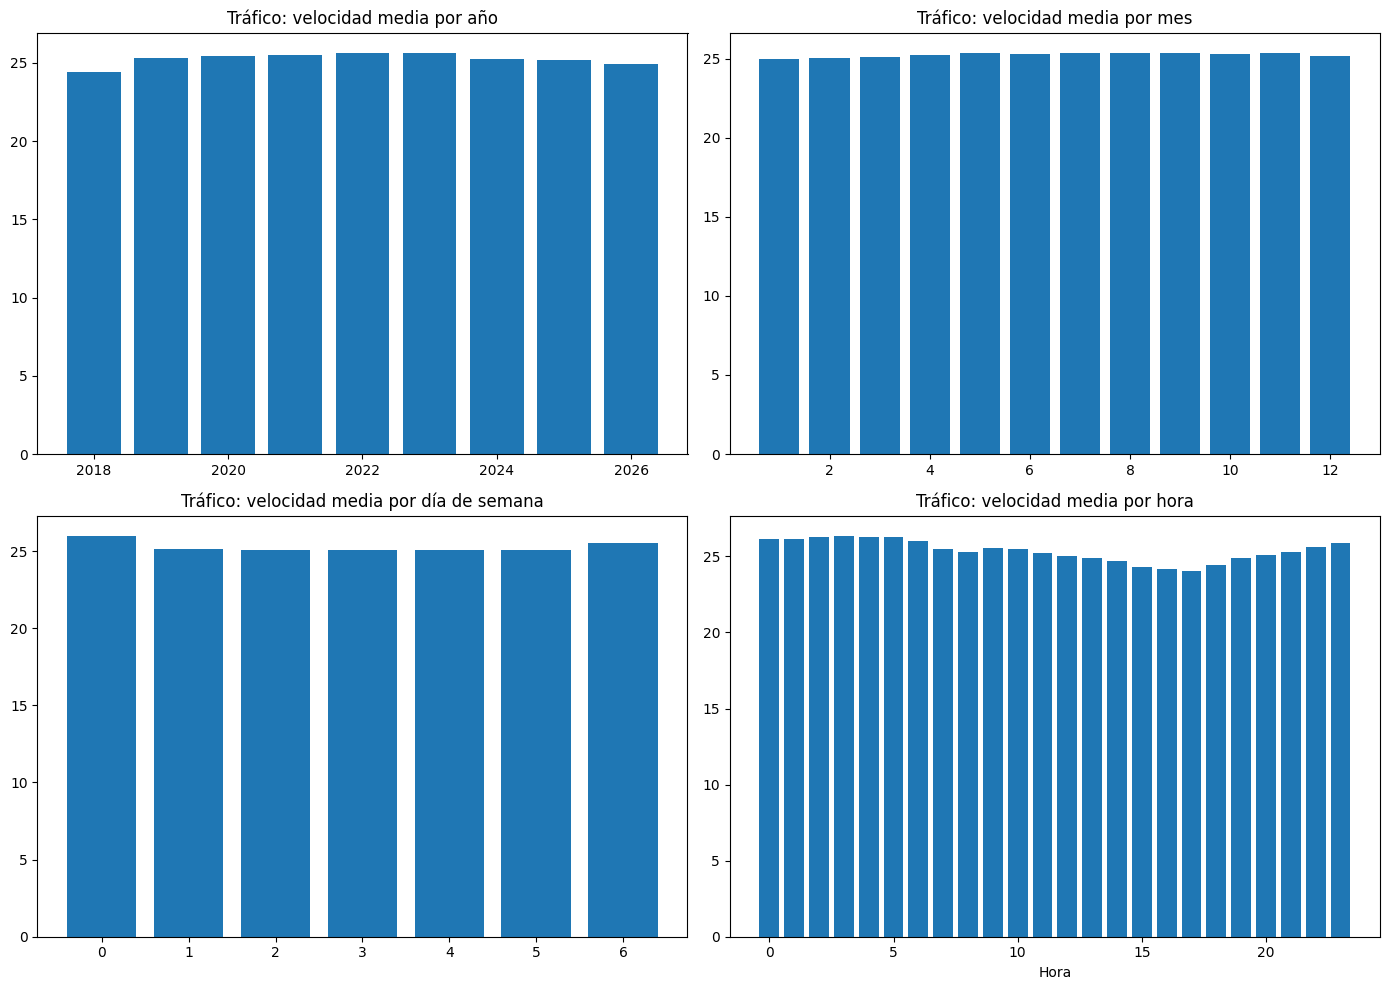

In [155]:
analisis_temporal_duckdb(con, "data_clean/dataset_final.parquet")

Los datos que tenemos van de 2018-02-28 a las 17:00:00 a 2026-04-30 a la 01:00:00. Es decir, los años 2018 y 2026 estan incompletos, por lo que su velocidad media no es directamente comparable con la de los años completos.

Si observamos los graficos, a primera vista parecen bastante planos. El que más varía es el tráfico por hora, donde se aprecia que la velocidad más alta es de madrugada (poco tráfico) y más bajas a la tarde (15-18h, hora punta).

### 3.4. Análisis geográfico

In [156]:
def analisis_geografico_duckdb(con, tabla, dim_tabla="segmentos_norm", mostrar_heatmap=True):
    agregado = con.sql(f"""
        SELECT f.segment_id, AVG(f.avg_speed) AS velocidad_media
        FROM '{tabla}' f
        GROUP BY f.segment_id
    """).df()

    geo = con.sql(f"""
        SELECT segment_id, mid_lat, mid_lon FROM {dim_tabla}
    """).df().drop_duplicates(subset="segment_id")

    datos = agregado.merge(geo, on="segment_id")

    centro = [datos["mid_lat"].mean(), datos["mid_lon"].mean()]
    m = folium.Map(location=centro, zoom_start=11)

    if mostrar_heatmap:
        heat_data = datos[["mid_lat", "mid_lon", "velocidad_media"]].values.tolist()
        HeatMap(heat_data, radius=10, blur=15, max_zoom=13).add_to(m)

    return m, datos

In [ ]:
mapa, datos_geo = analisis_geografico_duckdb(con, "data_clean/dataset_final.parquet")
mapa

### 3.5. Análisis por calles

In [158]:
def analisis_calles_duckdb(con, tabla, dim_tabla="dim_segmentos", top=15):
    resultado = con.sql(f"""
        SELECT s.street, AVG(f.avg_speed) AS velocidad_media, COUNT(*) AS n
        FROM '{tabla}' f
        JOIN {dim_tabla} s ON f.segment_id = s.segment_id
        GROUP BY s.street
        ORDER BY n DESC
        LIMIT {top}
    """).df()
    print(resultado)

In [159]:
analisis_calles_duckdb(con, "data_clean/dataset_final.parquet", top=15)

                 street  velocidad_media        n
0               Pulaski        24.835817  4416252
1               Western        25.256841  4313483
2               Halsted        23.700945  3847546
3               Ashland        24.408784  3840595
4                Cicero        26.097497  2851494
5         Lake Shore Dr        44.016650  2326916
6           Irving Park        23.430477  2247993
7                 North        23.343365  1982542
8                Cermak        22.576432  1973265
9   Dr Martin L King Jr        24.658958  1953105
10               Archer        26.771559  1939925
11                 79th        24.500495  1883738
12            Roosevelt        23.968447  1771087
13                 87th        26.296617  1666395
14            Milwaukee        23.022864  1503619


Lake Shore Dr destaca bastante con un 44km/h de velocidad media, muy superior al resto de vías. Esto es muy coherente ya que es la única vía de tipo autopista en el ranking, por lo que la comparación entre calles debe interpretarse teniendo en cuenta las características de cada segmento

### 3.6. Efecto por evento
A continuación, vamos a ver si los eventos integrados (accidentes, partidos, etc.) hacen una diferencia en la velocidad media del tráfico. Para eso vamos a calcular la velocidad media con y sin cada evento y lo visualizamos.

In [160]:
# velocidad media por presencia de cada evento
resumen_eventos = con.sql("""
    SELECT 'accidente_tipo' AS evento, accidente_tipo::VARCHAR AS valor, AVG(avg_speed) AS velocidad_media, COUNT(*) AS n
    FROM 'data_clean/dataset_final.parquet' GROUP BY accidente_tipo
    UNION ALL
    SELECT 'partido', partido::VARCHAR, AVG(avg_speed), COUNT(*)
    FROM 'data_clean/dataset_final.parquet' GROUP BY partido
    UNION ALL
    SELECT 'concierto', concierto::VARCHAR, AVG(avg_speed), COUNT(*)
    FROM 'data_clean/dataset_final.parquet' GROUP BY concierto
    UNION ALL
    SELECT 'obra_tipo', obra_tipo, AVG(avg_speed), COUNT(*)
    FROM 'data_clean/dataset_final.parquet' GROUP BY obra_tipo
    UNION ALL
    SELECT 'festivo', festivo::VARCHAR, AVG(avg_speed), COUNT(*)
    FROM 'data_clean/dataset_final.parquet' GROUP BY festivo
""").df()

print(resumen_eventos)

            evento        valor  velocidad_media         n
0   accidente_tipo      ninguno        25.297702  53543296
1   accidente_tipo         leve        23.196966     53580
2   accidente_tipo  sin_heridos        22.962202    599302
3   accidente_tipo        grave        23.358232     24017
4   accidente_tipo        fatal        23.513817      1936
5          partido            0        25.272241  53911067
6          partido            1        24.688038    311064
7        concierto            0        25.271732  54079987
8        concierto            1        24.187390    142144
9        obra_tipo      Partial        22.887143   7417971
10       obra_tipo         Full        24.016660   1894221
11       obra_tipo      ninguna        26.376643  32357575
12       obra_tipo     Curblane        24.011324  12547971
13       obra_tipo   Intermitte        19.663791      4393
14         festivo            0        25.261351  52202015
15         festivo            1        25.463696   20201

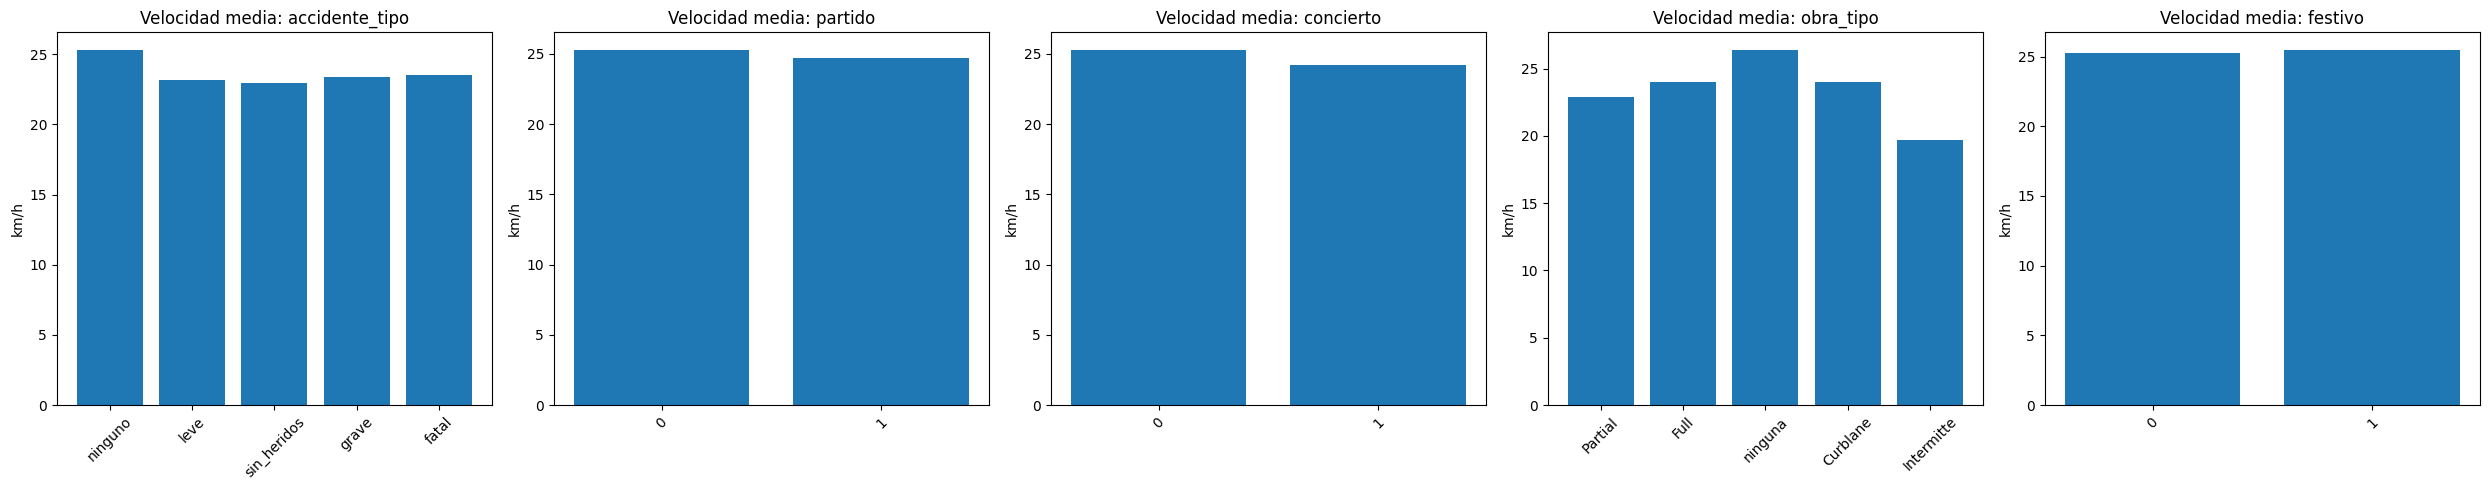

In [161]:
eventos_lista = resumen_eventos["evento"].unique()
fig, axes = plt.subplots(1, len(eventos_lista), figsize=(5 * len(eventos_lista), 5))

for ax, evento in zip(axes, eventos_lista):
    datos = resumen_eventos[resumen_eventos["evento"] == evento]
    ax.bar(datos["valor"], datos["velocidad_media"])
    ax.set_title(f"Velocidad media: {evento}")
    ax.set_ylabel("km/h")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Si nos fijamos en el orden de `accidente_tipo`, vemos que `sin_heridos` tiene la menor velocidad (22.96) mientras que `fatal` tiene la mayor (23.51), cuando lo lógico sería que fuera al reves (por lo que vimos en el análisis de ventanas). 

Esto ocurre ya que esta tabla compara la velocidad media absoluta de cada categoría sin tener en cuenta el tipo de calle, los accidentes graves o fatales tienden a ser en vías más rápidas (autopistas, etc.) mientras que los accidentes leves o sin heridos tienden a ser en calles urbanas de velocidad más baja. Además los accidentes `fatal`/`grave` (1.936 y 24.017) ocurren con mucha menos frecuencia que `leve`/`sin_heridos` (53.580 y 599.302).

Por lo tanto, el análisis de ventanas es más correcto para sacar conclusiones de este tipo.